Cargando 2 archivos .mseed desde C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\02_Sismos_seleccionados...
Estaciones detectadas: ['HEL', 'LCBC', 'OCA', 'PRV', 'RUS', 'SJC', 'SMAR', 'TUM', 'URI']

Aplicando Spectrum Matching a la estación: HEL...


c:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\venv\Lib\site-packages\obspy\signal\filter.py:87: UserWarning: Selected high corner frequency (25.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


Aplicando Spectrum Matching a la estación: LCBC...
Aplicando Spectrum Matching a la estación: OCA...
Aplicando Spectrum Matching a la estación: PRV...
Aplicando Spectrum Matching a la estación: RUS...
Aplicando Spectrum Matching a la estación: SJC...
Aplicando Spectrum Matching a la estación: SMAR...
Aplicando Spectrum Matching a la estación: TUM...
Aplicando Spectrum Matching a la estación: URI...


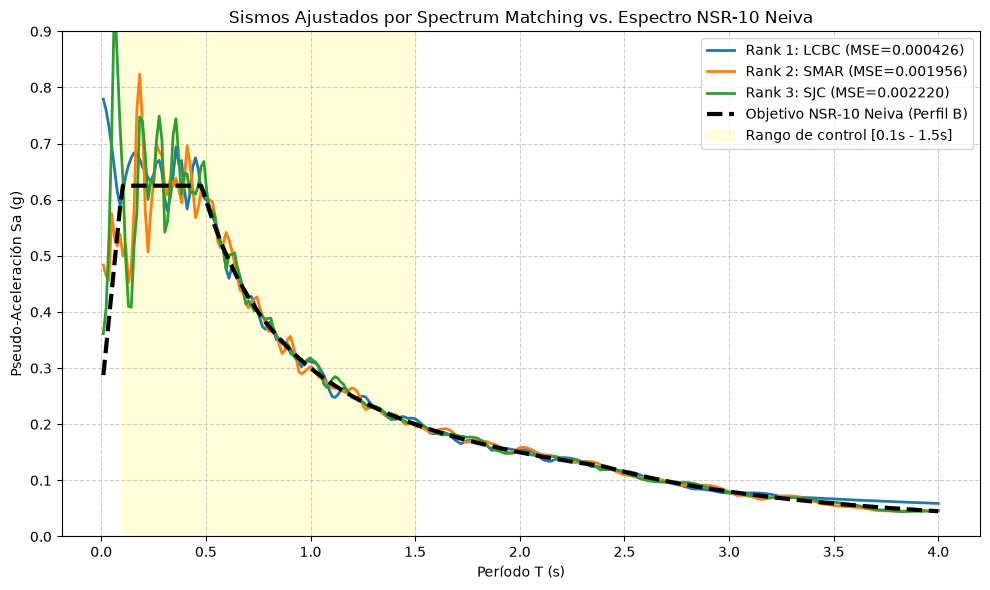


AJUSTE ESPECTRALS COMPLETADO CON ÉXITO. RESULTADOS GUARDADOS EN:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\02_Sismos_seleccionados
 Ranking Estacion_Sismo Canales_Exportados  Error_MSE  PGA_Max_H1_g  PGA_Max_H2_g
       1           LCBC     ['BHE', 'BHN']   0.000426         0.487         0.628
       2           SMAR     ['BHE', 'BHN']   0.001956         0.314         0.780
       3            SJC     ['BHE', 'BHN']   0.002220         0.273         0.455


In [3]:
import os
import glob
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Detectar función de integración compatible con NumPy 1.x y 2.x
trapezoid_func = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

# =============================================================================
# 1. CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# =============================================================================
CARPETA_MSEED = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\02_Sismos_seleccionados"
DIR_SALIDA = CARPETA_MSEED  # Guarda todos los resultados en la misma carpeta

# Parámetros del Ajuste Espectral (Spectrum Matching)
NUM_ITERACIONES = 6         # Número de iteraciones de ajuste FFT
SIGMA_SUAVIZADO = 3.0       # Suavizado gaussiano para mantener coherencia física
T_MIN_RANGO, T_MAX_RANGO = 0.1, 1.5
NUM_ESTACIONES_A_SELECCIONAR = 3

# =============================================================================
# 2. FUNCIONES MATEMÁTICAS Y ESPECTRALES
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    """Normaliza las unidades de la traza a 'g' (aceleración de la gravedad)."""
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))
    if pga_raw > 1000.0:
        return (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:
        return (datos / 100.0) / 9.81
    elif pga_raw > 1.5:
        return datos / 9.81
    else:
        return datos

def espectro_nsr10_neiva_roca(periodos):
    """Espectro de diseño elástico NSR-10 para Neiva en Perfil de Roca (Tipo B)."""
    Aa, Av = 0.25, 0.25
    Fa, Fv = 1.0, 1.0
    T0, TC, TL = 0.10, 0.48, 2.40
    
    Sa_norma = np.zeros(len(periodos))
    for idx, T in enumerate(periodos):
        if T < T0:
            Sa_norma[idx] = Aa * Fa * (1.0 + 1.5 * (T / T0))
        elif T0 <= T <= TC:
            Sa_norma[idx] = 2.5 * Aa * Fa
        elif TC < T <= TL:
            Sa_norma[idx] = (1.2 * Av * Fv) / T
        else:
            Sa_norma[idx] = (1.2 * Av * Fv * TL) / (T**2)
    return Sa_norma

def calcular_espectro_newmark(acc_g, dt, periodos, damping=0.05):
    """Calcula el espectro de respuesta mediante la integración numérica de Newmark-Beta."""
    acc_m_s2 = acc_g * 9.81
    Sa_g = np.zeros(len(periodos))
    gamma, beta = 0.5, 0.25
    N = len(acc_m_s2)

    for idx, T in enumerate(periodos):
        if T <= 0:
            Sa_g[idx] = np.max(np.abs(acc_g))
            continue
        omega = 2.0 * np.pi / T
        m = 1.0
        c = 2.0 * damping * omega * m
        k = (omega ** 2) * m

        k_hat = k + (gamma / (beta * dt)) * c + (1.0 / (beta * dt**2)) * m
        a_const = (1.0 / (beta * dt)) * m + (gamma / beta) * c
        b_const = (1.0 / (2.0 * beta)) * m + dt * ((gamma / (2.0 * beta)) - 1.0) * c

        u, v, a_rel = np.zeros(N), np.zeros(N), np.zeros(N)
        a_rel[0] = -acc_m_s2[0]

        for i in range(N - 1):
            df = -m * (acc_m_s2[i+1] - acc_m_s2[i]) + a_const * v[i] + b_const * a_rel[i]
            du = df / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v[i] + dt * (1.0 - gamma / (2.0 * beta)) * a_rel[i]
            da = (1.0 / (beta * dt**2)) * du - (1.0 / (beta * dt)) * v[i] - (1.0 / (2.0 * beta)) * a_rel[i]
            u[i+1], v[i+1], a_rel[i+1] = u[i] + du, v[i] + dv, a_rel[i] + da

        Sa_m_s2 = (omega ** 2) * np.max(np.abs(u))
        Sa_g[idx] = Sa_m_s2 / 9.81

    return Sa_g

def aplicar_spectrum_matching_fft(acc_g, dt, periodos, Sa_target, max_iter=6, sigma=3.0):
    """
    Ajusta iterativamente la aceleración en el dominio de la frecuencia 
    para amoldar su espectro de respuesta al espectro objetivo NSR-10.
    """
    acc = acc_g.copy()
    N = len(acc)
    freqs = np.fft.rfftfreq(N, d=dt)
    
    freqs_clean = freqs.copy()
    freqs_clean[0] = 1e-5
    periodos_freq = 1.0 / freqs_clean

    for it in range(max_iter):
        Sa_current = calcular_espectro_newmark(acc, dt, periodos)
        
        # Mapear espectros a las frecuencias de Fourier
        Sa_curr_f = np.interp(periodos_freq, periodos, Sa_current, left=Sa_current[0], right=Sa_current[-1])
        Sa_targ_f = np.interp(periodos_freq, periodos, Sa_target, left=Sa_target[0], right=Sa_target[-1])
        
        # Factor de escala por frecuencia con suavizado para evitar artefactos
        ratio = Sa_targ_f / np.maximum(Sa_curr_f, 1e-5)
        ratio_smooth = gaussian_filter1d(ratio, sigma=sigma)
        ratio_smooth = np.clip(ratio_smooth, 0.2, 5.0)
        
        # Transformación FFT y modificación de amplitudes
        FFT = np.fft.rfft(acc)
        FFT_adj = FFT * ratio_smooth
        
        acc = np.fft.irfft(FFT_adj, n=N)
        acc = acc - np.mean(acc) # Corrección de línea base
    
    Sa_final = calcular_espectro_newmark(acc, dt, periodos)
    return acc, Sa_final

# =============================================================================
# 3. LECTURA Y PROCESAMIENTO DE REGISTROS MSEED
# =============================================================================
archivos_mseed = glob.glob(os.path.join(CARPETA_MSEED, "*.mseed"))

if not archivos_mseed:
    raise FileNotFoundError(f"No se encontraron archivos .mseed en la carpeta: {CARPETA_MSEED}")

print(f"Cargando {len(archivos_mseed)} archivos .mseed desde {CARPETA_MSEED}...")
st = obspy.Stream()
for archivo in archivos_mseed:
    try:
        st += obspy.read(archivo)
    except Exception as e:
        print(f"  ⚠️ Error al leer {os.path.basename(archivo)}: {e}")

periodos = np.linspace(0.01, 4.0, 300)
Sa_target = espectro_nsr10_neiva_roca(periodos)

estaciones_disponibles = sorted(list(set(tr.stats.station for tr in st)))
print(f"Estaciones detectadas: {estaciones_disponibles}\n")

estaciones_procesadas = {}

for estacion in estaciones_disponibles:
    trazas_horiz = [tr for tr in st if tr.stats.station == estacion 
                    and not tr.stats.channel.endswith("Z")]
    
    if len(trazas_horiz) < 2:
        continue

    trazas_horiz = trazas_horiz[:2]
    datos_estacion = {"estacion": estacion, "componentes": {}}

    print(f"Aplicando Spectrum Matching a la estación: {estacion}...")

    for tr in trazas_horiz:
        canal = tr.stats.channel
        tr_proc = tr.copy()
        tr_proc.detrend("linear")
        tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

        dt = tr_proc.stats.delta
        acc_g_orig = normalizar_aceleracion_a_g(tr_proc)
        tiempo = np.arange(len(acc_g_orig)) * dt

        # Aplicar Ajuste Espectral (Spectrum Matching)
        acc_g_matched, Sa_matched = aplicar_spectrum_matching_fft(
            acc_g_orig, dt, periodos, Sa_target, 
            max_iter=NUM_ITERACIONES, sigma=SIGMA_SUAVIZADO
        )

        datos_estacion["componentes"][canal] = {
            "tiempo": tiempo,
            "dt": dt,
            "acc_g_matched": acc_g_matched,
            "Sa_matched": Sa_matched
        }

    # Media Geométrica Espectral del par ajustado
    canales = list(datos_estacion["componentes"].keys())
    Sa_h1 = datos_estacion["componentes"][canales[0]]["Sa_matched"]
    Sa_h2 = datos_estacion["componentes"][canales[1]]["Sa_matched"]
    Sa_geomean_matched = np.sqrt(Sa_h1 * Sa_h2)

    # Evaluación de ajuste (MSE)
    mask = (periodos >= T_MIN_RANGO) & (periodos <= T_MAX_RANGO)
    MSE = np.mean((Sa_geomean_matched[mask] - Sa_target[mask])**2)

    datos_estacion["MSE"] = MSE
    datos_estacion["Sa_geomean_matched"] = Sa_geomean_matched
    estaciones_procesadas[estacion] = datos_estacion

# =============================================================================
# 4. RANKING Y EXPORTACIÓN DE RESULTADOS
# =============================================================================
if not estaciones_procesadas:
    print("❌ No se pudieron procesar pares horizontales.")
else:
    estaciones_ordenadas = sorted(estaciones_procesadas.values(), key=lambda x: x["MSE"])
    num_seleccionar = min(NUM_ESTACIONES_A_SELECCIONAR, len(estaciones_ordenadas))
    estaciones_top = estaciones_ordenadas[:num_seleccionar]

    plt.figure(figsize=(10, 6))
    resumen_exportacion = []

    for idx, est_data in enumerate(estaciones_top, 1):
        nom_est = est_data["estacion"]
        MSE = est_data["MSE"]

        # Exportación de archivos CSV de aceleración ajustada por Spectrum Matching
        for canal, comp in est_data["componentes"].items():
            df_acc = pd.DataFrame({
                "Tiempo_s": comp["tiempo"],
                "Aceleracion_g": comp["acc_g_matched"]
            })
            archivo_salida = os.path.join(DIR_SALIDA, f"Matched_Rank{idx}_{nom_est}_{canal}.csv")
            df_acc.to_csv(archivo_salida, index=False)

        # Graficar curva ajustada de la media geométrica
        plt.plot(periodos, est_data["Sa_geomean_matched"], lw=2.0,
                 label=f"Rank {idx}: {nom_est} (MSE={MSE:.6f})")

        resumen_exportacion.append({
            "Ranking": idx,
            "Estacion_Sismo": nom_est,
            "Canales_Exportados": f"{list(est_data['componentes'].keys())}",
            "Error_MSE": round(MSE, 6),
            "PGA_Max_H1_g": round(np.max(np.abs(list(est_data['componentes'].values())[0]['acc_g_matched'])), 3),
            "PGA_Max_H2_g": round(np.max(np.abs(list(est_data['componentes'].values())[1]['acc_g_matched'])), 3),
        })

    # Curva Objetivo NSR-10 Neiva
    plt.plot(periodos, Sa_target, color="black", lw=3.0, linestyle="--", label="Objetivo NSR-10 Neiva (Perfil B)")
    plt.axvspan(T_MIN_RANGO, T_MAX_RANGO, color='yellow', alpha=0.15, label=f"Rango de control [{T_MIN_RANGO}s - {T_MAX_RANGO}s]")

    plt.title(f"Sismos Ajustados por Spectrum Matching vs. Espectro NSR-10 Neiva")
    plt.xlabel("Período T (s)")
    plt.ylabel("Pseudo-Aceleración Sa (g)")
    plt.ylim(0, max(0.9, np.max(Sa_target) * 1.2))
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()

    # Guardar gráfica y reporte CSV
    plt.savefig(os.path.join(DIR_SALIDA, "Espectros_Ajustados_Spectrum_Matching.png"), dpi=300)
    plt.show()

    df_reporte = pd.DataFrame(resumen_exportacion)
    df_reporte.to_csv(os.path.join(DIR_SALIDA, "Reporte_Ajuste_Espectral.csv"), index=False)

    print("\n" + "="*95)
    print(f"AJUSTE ESPECTRALS COMPLETADO CON ÉXITO. RESULTADOS GUARDADOS EN:\n{DIR_SALIDA}")
    print("="*95)
    print(df_reporte.to_string(index=False))